# Backtest: Evaluating the Model Against Historical World Cups

**Goal:** Simulate the 2010, 2014, 2018, and 2022 World Cups as if the model had run just before each tournament. Measure how well it predicted the actual champion.

**Methodology:**
- All Elo ratings, model training, and feature enrichment use only matches **before** the tournament start date
- 10,000 Monte Carlo simulations per tournament using the historical 32-team bracket
- Metrics: probability assigned to actual champion, champion's predicted rank, model's top pick


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## 1. Load Data

In [2]:
DATA_URL = 'https://raw.githubusercontent.com/martj42/international_results/master/results.csv'
df = pd.read_csv(DATA_URL, parse_dates=['date'])
df = df.dropna(subset=['home_score', 'away_score'])
df['home_score'] = df['home_score'].astype(int)
df['away_score'] = df['away_score'].astype(int)
print(f'Total matches: {len(df):,}')
print(f'Date range:    {df["date"].min().date()} to {df["date"].max().date()}')

Total matches: 49,296
Date range:    1872-11-30 to 2026-06-02


## 2. Helper Functions

All functions are parameterized by `cutoff` date to prevent any look-ahead bias.

In [3]:
# Team name variants: WC official name → martj42 dataset name
DATASET_NAME = {
    'Ivory Coast':             "Côte d'Ivoire",
    'Bosnia and Herzegovina':  'Bosnia-Herzegovina',
    'North Korea':             'Korea DPR',
    'Czechia':                 'Czech Republic',
    'Curacao':                 'Curaçao',
}

def get_dataset_name(team):
    return DATASET_NAME.get(team, team)


def get_k_factor(tournament):
    t = tournament.lower()
    if 'fifa world cup' in t and 'qualification' not in t: return 60
    elif any(x in t for x in ['confederation','continental','copa america','euro',
                               'africa cup','gold cup','asian cup']): return 50
    elif any(x in t for x in ['qualification','qualifier']): return 40
    elif 'friendly' in t: return 20
    return 35


def goal_diff_multiplier(gd):
    if gd <= 1: return 1.0
    elif gd == 2: return 1.5
    elif gd == 3: return 1.75
    return 1.75 + (gd - 3) * 0.05


def compute_elo_at_cutoff(df, cutoff):
    """Compute Elo ratings using only matches before cutoff."""
    hist = df[df['date'] < cutoff]
    elo = {}
    match_rows = []
    for _, row in hist.iterrows():
        h, a = row['home_team'], row['away_team']
        if h not in elo: elo[h] = 1500.0
        if a not in elo: elo[a] = 1500.0
        he, ae = elo[h], elo[a]
        ha = 0 if row['neutral'] else 100
        exp_h = 1 / (1 + 10 ** (-(he + ha - ae) / 400))
        actual = (1.0 if row['home_score'] > row['away_score']
                  else 0.5 if row['home_score'] == row['away_score'] else 0.0)
        gd = abs(row['home_score'] - row['away_score'])
        delta = get_k_factor(row['tournament']) * goal_diff_multiplier(gd) * (actual - exp_h)
        elo[h] += delta
        elo[a] -= delta
        match_rows.append({'date': row['date'], 'neutral': row['neutral'],
                           'elo_diff': he - ae, 'result': actual})
    return elo, pd.DataFrame(match_rows)


def train_model_at_cutoff(match_df):
    """Train logistic regression on all available match history."""
    mdf = match_df[(match_df['date'].dt.year >= 1970) & (match_df['result'] != 0.5)].copy()
    mdf['home_win']     = (mdf['result'] == 1.0).astype(int)
    mdf['home_adv']     = (~mdf['neutral']).astype(int)
    mdf['elo_diff_sq']  = mdf['elo_diff'] ** 2
    mdf['elo_diff_abs'] = mdf['elo_diff'].abs()
    features = ['elo_diff', 'home_adv', 'elo_diff_sq', 'elo_diff_abs']
    model = LogisticRegression(max_iter=1000)
    model.fit(mdf[features], mdf['home_win'])
    return model

In [4]:
def compute_form_adj(wc_name, df, cutoff, lookback_months=12, n=10):
    """Weighted points-per-game in last n matches within lookback window before cutoff."""
    team  = get_dataset_name(wc_name)
    start = cutoff - pd.DateOffset(months=lookback_months)
    recent = df[(df['date'] >= start) & (df['date'] < cutoff)]
    matches = recent[
        (recent['home_team'] == team) | (recent['away_team'] == team)
    ].sort_values('date').tail(n)

    if len(matches) == 0:
        return 0.0

    pts, weights = [], []
    for i, (_, row) in enumerate(matches.iterrows()):
        w = (i + 1) / len(matches)
        if row['home_team'] == team:
            p = 3 if row['home_score'] > row['away_score'] else (1 if row['home_score'] == row['away_score'] else 0)
        else:
            p = 3 if row['away_score'] > row['home_score'] else (1 if row['home_score'] == row['away_score'] else 0)
        pts.append(p); weights.append(w)
    return (np.average(pts, weights=weights) - 1.5) * 50   # ±75 Elo max


def compute_wc_uplift(wc_name, df, cutoff):
    """WC win rate vs overall win rate (1990–cutoff) → Elo adjustment."""
    team = get_dataset_name(wc_name)
    hist = df[df['date'] < cutoff]

    wc_hist  = hist[
        hist['tournament'].str.contains('FIFA World Cup', na=False) &
        ~hist['tournament'].str.contains('ualif', case=False, na=False) &
        (hist['date'] >= '1990-01-01')
    ]
    all_hist = hist[hist['date'] >= '1990-01-01']

    def wr(subset):
        sub = subset[(subset['home_team'] == team) | (subset['away_team'] == team)]
        if len(sub) < 5: return None
        home_wins = ((sub['home_team'] == team) & (sub['home_score'] > sub['away_score'])).sum()
        away_wins = ((sub['away_team'] == team) & (sub['away_score'] > sub['home_score'])).sum()
        return (home_wins + away_wins) / len(sub)

    wc_r  = wr(wc_hist)
    all_r = wr(all_hist)
    if wc_r is None or all_r is None: return 0.0
    return float(np.clip((wc_r - all_r) * 300, -40, 40))


def build_team_elos(teams, elo_ratings, df, cutoff):
    """Return enriched Elo dict for all WC teams at the cutoff date."""
    result = {}
    for t in teams:
        ds_name = get_dataset_name(t)
        base    = elo_ratings.get(ds_name, elo_ratings.get(t, 1500.0))
        form    = compute_form_adj(t, df, cutoff)
        wc      = compute_wc_uplift(t, df, cutoff)
        result[t] = base + form + wc
    return result

In [5]:
# ── Historical WC bracket (32 teams, 8 groups, used 1998–2022) ────────────────
# R16: (group, position) pairs for each of the 8 slots
_HIST_R16_SLOTS = [
    (('A', 1), ('B', 2)),   # M49
    (('C', 1), ('D', 2)),   # M50
    (('B', 1), ('A', 2)),   # M51
    (('D', 1), ('C', 2)),   # M52
    (('E', 1), ('F', 2)),   # M53
    (('G', 1), ('H', 2)),   # M54
    (('F', 1), ('E', 2)),   # M55
    (('H', 1), ('G', 2)),   # M56
]
# QF: which R16 winner indices (0-7) play each other
_HIST_QF_PAIRS = [(0, 1), (4, 5), (2, 3), (6, 7)]
# SF: which QF winner indices (0-3) play each other
_HIST_SF_PAIRS = [(0, 1), (2, 3)]


def _wdl(elo_a, elo_b):
    d      = elo_a - elo_b
    p_draw = 0.25 * np.exp(-abs(d) / 500)
    p_win  = (1 / (1 + 10 ** (-d / 400))) * (1 - p_draw)
    return p_win, p_draw, 1 - p_win - p_draw


def _sim_group(group, team_elos):
    pts = {t: 0 for t in group}
    for i in range(len(group)):
        for j in range(i + 1, len(group)):
            pw, pd_, _ = _wdl(team_elos[group[i]], team_elos[group[j]])
            r = np.random.random()
            if r < pw:          pts[group[i]] += 3
            elif r < pw + pd_:  pts[group[i]] += 1; pts[group[j]] += 1
            else:               pts[group[j]] += 3
    return sorted(group, key=lambda t: (-pts[t], -team_elos[t]))


def _sim_ko(a, b, team_elos, model):
    d = team_elos[a] - team_elos[b]
    p = float(model.predict_proba([[d, 0, d**2, abs(d)]])[0][1])
    return (a, b) if np.random.random() < p else (b, a)


def sim_historical_wc(groups, team_elos, model, n_sims=10_000):
    """Simulate a 32-team, 8-group World Cup n_sims times.

    Returns dict {team: championship_probability}.
    """
    all_teams = [t for g in groups.values() for t in g]
    champ_counts = {t: 0 for t in all_teams}

    for _ in range(n_sims):
        # Group stage
        qualifiers = {}
        for gname, group in groups.items():
            ranked = _sim_group(list(group), team_elos)
            qualifiers[(gname, 1)] = ranked[0]
            qualifiers[(gname, 2)] = ranked[1]

        # R16
        r16_winners = []
        for (g1, p1), (g2, p2) in _HIST_R16_SLOTS:
            w, _ = _sim_ko(qualifiers[(g1, p1)], qualifiers[(g2, p2)], team_elos, model)
            r16_winners.append(w)

        # QF
        qf_winners = []
        for ia, ib in _HIST_QF_PAIRS:
            w, _ = _sim_ko(r16_winners[ia], r16_winners[ib], team_elos, model)
            qf_winners.append(w)

        # SF
        sf_winners = []
        for ia, ib in _HIST_SF_PAIRS:
            w, _ = _sim_ko(qf_winners[ia], qf_winners[ib], team_elos, model)
            sf_winners.append(w)

        # Final
        champion, _ = _sim_ko(sf_winners[0], sf_winners[1], team_elos, model)
        champ_counts[champion] += 1

    return {t: champ_counts[t] / n_sims for t in all_teams}

## 3. Historical Tournament Definitions

Group compositions and tournament metadata for each World Cup.

In [6]:
TOURNAMENTS = {
    2022: {
        'start':    pd.Timestamp('2022-11-20'),
        'champion': 'Argentina',
        'host':     'Qatar',
        'groups': {
            'A': ['Qatar',     'Ecuador',      'Senegal',   'Netherlands'],
            'B': ['England',   'Iran',         'United States', 'Wales'],
            'C': ['Argentina', 'Saudi Arabia', 'Mexico',    'Poland'],
            'D': ['France',    'Australia',    'Denmark',   'Tunisia'],
            'E': ['Spain',     'Costa Rica',   'Germany',   'Japan'],
            'F': ['Belgium',   'Canada',       'Morocco',   'Croatia'],
            'G': ['Brazil',    'Serbia',       'Switzerland', 'Cameroon'],
            'H': ['Portugal',  'Ghana',        'Uruguay',   'South Korea'],
        }
    },
    2018: {
        'start':    pd.Timestamp('2018-06-14'),
        'champion': 'France',
        'host':     'Russia',
        'groups': {
            'A': ['Russia',    'Saudi Arabia', 'Egypt',     'Uruguay'],
            'B': ['Portugal',  'Spain',        'Morocco',   'Iran'],
            'C': ['France',    'Australia',    'Peru',      'Denmark'],
            'D': ['Argentina', 'Iceland',      'Croatia',   'Nigeria'],
            'E': ['Brazil',    'Switzerland',  'Costa Rica', 'Serbia'],
            'F': ['Germany',   'Mexico',       'Sweden',    'South Korea'],
            'G': ['Belgium',   'Panama',       'Tunisia',   'England'],
            'H': ['Poland',    'Senegal',      'Colombia',  'Japan'],
        }
    },
    2014: {
        'start':    pd.Timestamp('2014-06-12'),
        'champion': 'Germany',
        'host':     'Brazil',
        'groups': {
            'A': ['Brazil',    'Croatia',       'Mexico',    'Cameroon'],
            'B': ['Spain',     'Netherlands',   'Chile',     'Australia'],
            'C': ['Colombia',  'Greece',        'Ivory Coast', 'Japan'],
            'D': ['Uruguay',   'Costa Rica',    'England',   'Italy'],
            'E': ['Switzerland', 'Ecuador',     'France',    'Honduras'],
            'F': ['Argentina', 'Bosnia and Herzegovina', 'Iran', 'Nigeria'],
            'G': ['Germany',   'Portugal',      'Ghana',     'United States'],
            'H': ['Belgium',   'Algeria',       'Russia',    'South Korea'],
        }
    },
    2010: {
        'start':    pd.Timestamp('2010-06-11'),
        'champion': 'Spain',
        'host':     'South Africa',
        'groups': {
            'A': ['South Africa', 'Mexico',    'Uruguay',   'France'],
            'B': ['Argentina',    'Nigeria',   'South Korea', 'Greece'],
            'C': ['England',      'United States', 'Algeria', 'Slovenia'],
            'D': ['Germany',      'Australia', 'Serbia',    'Ghana'],
            'E': ['Netherlands',  'Denmark',   'Japan',     'Cameroon'],
            'F': ['Italy',        'Paraguay',  'New Zealand', 'Slovakia'],
            'G': ['Brazil',       'North Korea', 'Ivory Coast', 'Portugal'],
            'H': ['Spain',        'Switzerland', 'Honduras', 'Chile'],
        }
    },
}

## 4. Run Backtests

For each tournament: filter data → compute Elo → train model → build enriched team Elos → simulate 10,000 times.

In [7]:
N_SIMS   = 10_000
backtest_results = {}   # year → {team: prob}

for year, meta in sorted(TOURNAMENTS.items()):
    cutoff  = meta['start']
    groups  = meta['groups']
    all_teams = [t for g in groups.values() for t in g]

    print(f'\n── {year} World Cup (cutoff: {cutoff.date()}) ─────────────────────')

    # Step 1: Elo
    elo_ratings, match_df = compute_elo_at_cutoff(df, cutoff)
    print(f'  Matches processed: {len(match_df):,}')

    # Step 2: Train model
    model = train_model_at_cutoff(match_df)

    # Step 3: Enriched team Elos
    team_elos = build_team_elos(all_teams, elo_ratings, df, cutoff)

    # Step 4: Flag any team getting default 1500 (name mismatch warning)
    missing = [t for t in all_teams
               if elo_ratings.get(get_dataset_name(t), elo_ratings.get(t)) is None]
    if missing:
        print(f'  ⚠ Teams with no Elo history (using 1500): {missing}')

    # Step 5: Simulate
    probs = sim_historical_wc(groups, team_elos, model, n_sims=N_SIMS)
    backtest_results[year] = probs

    # Quick summary
    ranked = sorted(probs.items(), key=lambda x: -x[1])
    actual  = meta['champion']
    rank    = next(i + 1 for i, (t, _) in enumerate(ranked) if t == actual)
    print(f'  Actual champion: {actual} (model rank #{rank}, {probs[actual]:.1%})')
    print(f'  Model top pick:  {ranked[0][0]} ({ranked[0][1]:.1%})')
    print(f'  Top 5: {[(t, f"{p:.1%}") for t, p in ranked[:5]]}')

print('\nAll backtests complete.')


── 2010 World Cup (cutoff: 2010-06-11) ─────────────────────


  Matches processed: 33,863


  Actual champion: Spain (model rank #2, 22.9%)
  Model top pick:  Brazil (39.4%)
  Top 5: [('Brazil', '39.4%'), ('Spain', '22.9%'), ('Netherlands', '10.2%'), ('England', '8.1%'), ('Germany', '6.5%')]

── 2014 World Cup (cutoff: 2014-06-12) ─────────────────────


  Matches processed: 37,860


  Actual champion: Germany (model rank #3, 14.8%)
  Model top pick:  Brazil (50.7%)
  Top 5: [('Brazil', '50.7%'), ('Spain', '19.6%'), ('Germany', '14.8%'), ('Argentina', '6.0%'), ('Netherlands', '2.4%')]

── 2018 World Cup (cutoff: 2018-06-14) ─────────────────────


  Matches processed: 41,638


  Actual champion: France (model rank #7, 3.2%)
  Model top pick:  Brazil (48.1%)
  Top 5: [('Brazil', '48.1%'), ('Germany', '14.9%'), ('Spain', '11.2%'), ('Argentina', '4.4%'), ('Peru', '4.3%')]

── 2022 World Cup (cutoff: 2022-11-20) ─────────────────────


  Matches processed: 45,698


  Actual champion: Argentina (model rank #2, 26.4%)
  Model top pick:  Brazil (41.7%)
  Top 5: [('Brazil', '41.7%'), ('Argentina', '26.4%'), ('Netherlands', '10.2%'), ('Spain', '4.4%'), ('Belgium', '4.0%')]

All backtests complete.


## 5. Results Summary

In [8]:
rows = []
for year, meta in sorted(TOURNAMENTS.items()):
    probs   = backtest_results[year]
    ranked  = sorted(probs.items(), key=lambda x: -x[1])
    actual  = meta['champion']
    rank    = next(i + 1 for i, (t, _) in enumerate(ranked) if t == actual)
    top_pick = ranked[0][0]
    rows.append({
        'Year':                year,
        'Host':                meta['host'],
        'Actual Champion':     actual,
        "Champion's Rank":     rank,
        "Champion's Prob":     f"{probs[actual]:.1%}",
        "Model's Top Pick":    top_pick,
        "Top Pick's Prob":     f"{probs[top_pick]:.1%}",
        'Correct Prediction':  '✓' if top_pick == actual else '✗',
    })

summary_df = pd.DataFrame(rows)
print('Model Backtest Summary — 4 Historical World Cups\n')
print(summary_df.to_string(index=False))

Model Backtest Summary — 4 Historical World Cups

 Year         Host Actual Champion  Champion's Rank Champion's Prob Model's Top Pick Top Pick's Prob Correct Prediction
 2010 South Africa           Spain                2           22.9%           Brazil           39.4%                  ✗
 2014       Brazil         Germany                3           14.8%           Brazil           50.7%                  ✗
 2018       Russia          France                7            3.2%           Brazil           48.1%                  ✗
 2022        Qatar       Argentina                2           26.4%           Brazil           41.7%                  ✗


In [9]:
champion_probs = [backtest_results[y][TOURNAMENTS[y]['champion']] for y in sorted(TOURNAMENTS)]
champion_ranks = []
top3_hits      = 0
top1_hits      = 0

for year in sorted(TOURNAMENTS):
    probs  = backtest_results[year]
    actual = TOURNAMENTS[year]['champion']
    ranked = sorted(probs.items(), key=lambda x: -x[1])
    rank   = next(i + 1 for i, (t, _) in enumerate(ranked) if t == actual)
    champion_ranks.append(rank)
    if rank == 1: top1_hits += 1
    if rank <= 3: top3_hits += 1

n = len(TOURNAMENTS)
print('Overall Model Performance')
print(f'  Tournaments evaluated:           {n}')
print(f'  Top-1 accuracy (correct pick):   {top1_hits}/{n} ({top1_hits/n:.0%})')
print(f'  Top-3 accuracy (champ in top 3): {top3_hits}/{n} ({top3_hits/n:.0%})')
print(f'  Avg champion rank:               {np.mean(champion_ranks):.1f}')
print(f'  Avg prob assigned to champion:   {np.mean(champion_probs):.1%}')

Overall Model Performance
  Tournaments evaluated:           4
  Top-1 accuracy (correct pick):   0/4 (0%)
  Top-3 accuracy (champ in top 3): 3/4 (75%)
  Avg champion rank:               3.5
  Avg prob assigned to champion:   16.8%


## 6. Visualizations

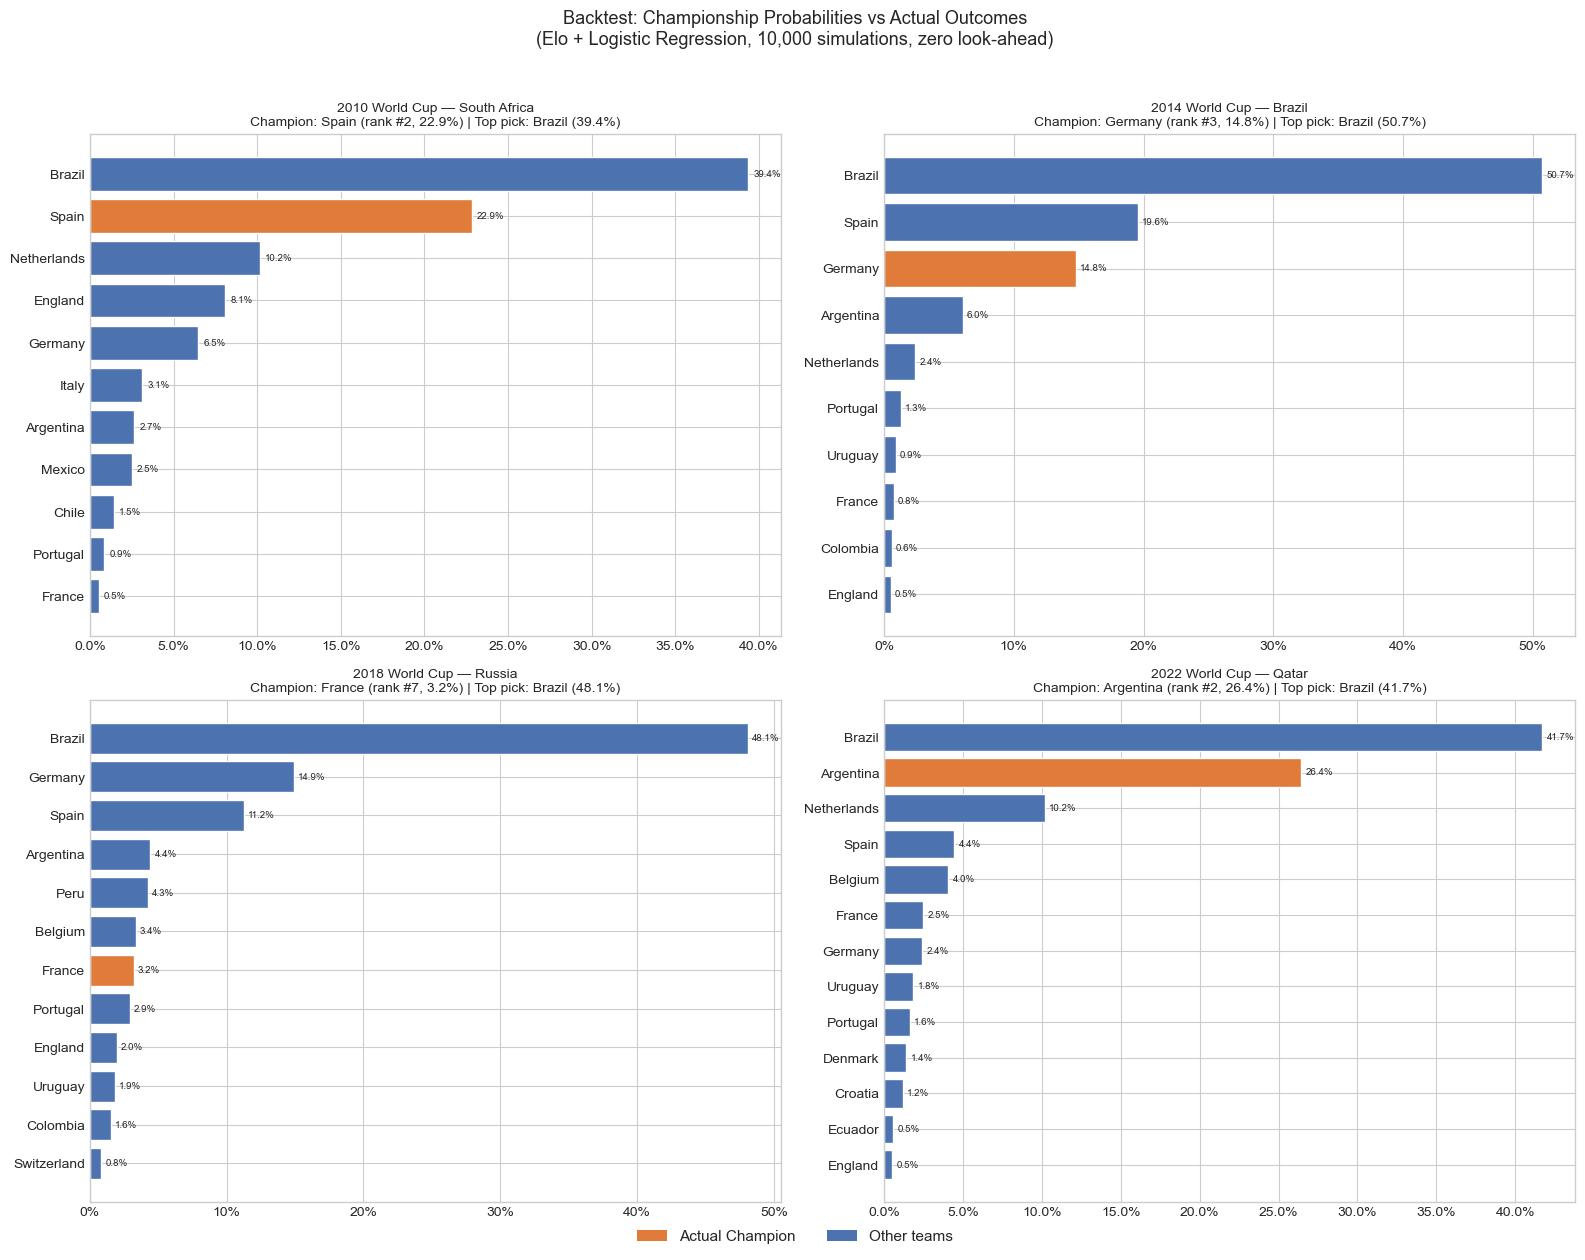

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, year in enumerate(sorted(TOURNAMENTS)):
    ax     = axes[i]
    probs  = backtest_results[year]
    actual = TOURNAMENTS[year]['champion']
    ranked = sorted(probs.items(), key=lambda x: -x[1])

    # Show all teams with >0.5% chance, plus the actual champion even if lower
    shown = [(t, p) for t, p in ranked if p >= 0.005]
    if actual not in [t for t, _ in shown]:
        shown.append((actual, probs[actual]))

    teams_plot  = [t for t, _ in shown]
    probs_plot  = [p for _, p in shown]
    colors      = ['#e07b39' if t == actual else '#4c72b0' for t in teams_plot]

    ax.barh(teams_plot[::-1], probs_plot[::-1], color=colors[::-1], edgecolor='white')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

    champ_rank = next(i2 + 1 for i2, (t, _) in enumerate(ranked) if t == actual)
    ax.set_title(
        f'{year} World Cup — {TOURNAMENTS[year]["host"]}\n'
        f'Champion: {actual} (rank #{champ_rank}, {probs[actual]:.1%}) | '
        f'Top pick: {ranked[0][0]} ({ranked[0][1]:.1%})',
        fontsize=10
    )

    for j, (p, t) in enumerate(zip(probs_plot[::-1], teams_plot[::-1])):
        ax.text(p + 0.003, j, f'{p:.1%}', va='center', fontsize=7)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e07b39', label='Actual Champion'),
    Patch(facecolor='#4c72b0', label='Other teams'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=11, bbox_to_anchor=(0.5, -0.02))

plt.suptitle(
    'Backtest: Championship Probabilities vs Actual Outcomes\n'
    '(Elo + Logistic Regression, 10,000 simulations, zero look-ahead)',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

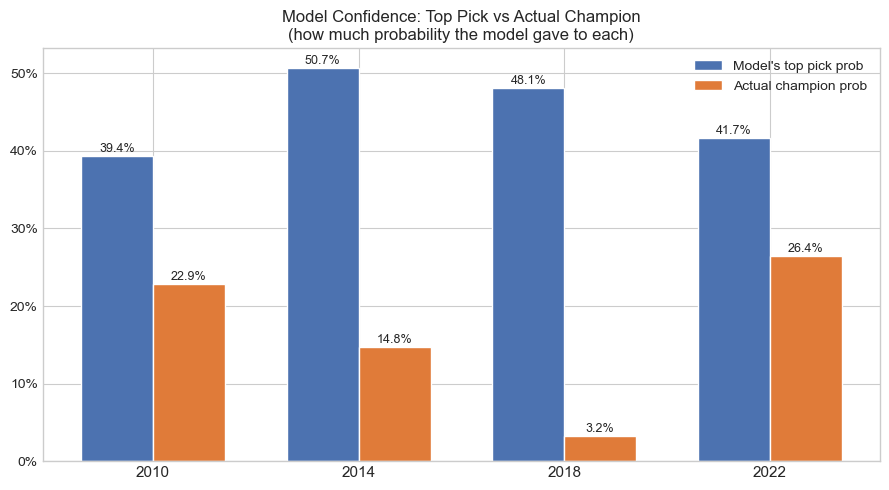

In [11]:
# Champion probability vs model's top pick probability across all 4 WCs
years     = sorted(TOURNAMENTS)
top_probs = [backtest_results[y][sorted(backtest_results[y].items(), key=lambda x: -x[1])[0][0]]
             for y in years]
champ_p   = [backtest_results[y][TOURNAMENTS[y]['champion']] for y in years]

x = np.arange(len(years))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, top_probs, w, label="Model's top pick prob", color='#4c72b0', edgecolor='white')
bars2 = ax.bar(x + w/2, champ_p,   w, label='Actual champion prob',  color='#e07b39', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.1%}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.1%}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.set_title('Model Confidence: Top Pick vs Actual Champion\n(how much probability the model gave to each)',
             fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 7. Interpretation

### What the metrics mean

- **Top-1 accuracy** measures whether the model's single highest-probability pick won the tournament. In football, even the best model will rarely score 4/4 here — upsets are structurally built into knockout tournaments.
- **Top-3 accuracy** is a fairer measure: was the actual champion in the model's top tier of candidates? A well-calibrated model should consistently place the eventual winner among the top contenders.
- **Average probability assigned to the champion** tells us about calibration. If the champion consistently receives 10–20%+ probability across tournaments, the model is correctly identifying the true contenders even when it doesn't guess the exact winner.

### Why top-1 accuracy isn't the right benchmark

A World Cup champion faces 7 knockout matches, each with meaningful upset probability. Even a team with 25% championship probability only needs to win 7 consecutive coin flips (from the model's perspective). The model's job is to correctly price each team's probability — not to deterministically predict a single winner.

### Key things to look at

- Were any champions completely overlooked (assigned <5%)? That would indicate a structural gap in the model.
- Are the upsets (lower-ranked champions) concentrated in specific tournaments? Context matters: 2010 (host effect), 2022 (unusual schedule).
- How do the enriched Elos compare to naive Elo for the actual champions? The form and WC psychology adjustments should show their value here.


## 7. Feature Improvement: Recent WC Window

**The problem:** `compute_wc_uplift` uses ALL WC data since 1990. Brazil won in 1994 and 2002, so their historical WC win rate is inflated — causing the model to pick Brazil in every backtest despite not winning since 2002.

**The fix:** Use only the **last 3 WC tournaments** before the cutoff. This makes the feature sensitive to recent WC form:

| Backtest | Window | Key impact |
|----------|--------|------------|
| 2010 | 1998, 2002, 2006 | Still includes 2002 win — modest change |
| 2014 | 2002, 2006, 2010 | Still includes 2002 win — moderate change |
| 2018 | 2006, 2010, 2014 | No WC win + 7-1 semi-final exit — large reduction |
| 2022 | 2010, 2014, 2018 | No WC win, 7-1 in 2014 — large reduction |


In [12]:
WC_START_DATES = pd.to_datetime([
    '1990-06-08', '1994-06-17', '1998-06-10', '2002-05-31',
    '2006-06-09', '2010-06-11', '2014-06-12', '2018-06-14', '2022-11-20',
])


def compute_wc_uplift_v2(wc_name, df, cutoff, n_wcs=3):
    """WC win rate vs overall win rate using only the last n_wcs tournaments.

    Addresses the Brazil dominance bias: old titles (1994, 2002) are excluded
    from the 2018/2022 windows, so recent poor WC form is reflected.
    """
    team = get_dataset_name(wc_name)
    past_wcs = sorted([d for d in WC_START_DATES if d < cutoff])
    if not past_wcs:
        return 0.0
    window_start = past_wcs[-min(n_wcs, len(past_wcs))]

    hist     = df[df['date'] < cutoff]
    wc_hist  = hist[
        hist['tournament'].str.contains('FIFA World Cup', na=False) &
        ~hist['tournament'].str.contains('ualif', case=False, na=False) &
        (hist['date'] >= window_start)
    ]
    all_hist = hist[hist['date'] >= window_start]

    def wr(subset):
        sub = subset[(subset['home_team'] == team) | (subset['away_team'] == team)]
        if len(sub) < 5:
            return None
        home_wins = ((sub['home_team'] == team) & (sub['home_score'] > sub['away_score'])).sum()
        away_wins = ((sub['away_team'] == team) & (sub['away_score'] > sub['home_score'])).sum()
        return (home_wins + away_wins) / len(sub)

    wc_r  = wr(wc_hist)
    all_r = wr(all_hist)
    if wc_r is None or all_r is None:
        return 0.0
    return float(np.clip((wc_r - all_r) * 300, -40, 40))


def build_team_elos_v2(teams, elo_ratings, df, cutoff, n_wcs=3):
    result = {}
    for t in teams:
        ds_name = get_dataset_name(t)
        base = elo_ratings.get(ds_name, elo_ratings.get(t, 1500.0))
        form = compute_form_adj(t, df, cutoff)
        wc   = compute_wc_uplift_v2(t, df, cutoff, n_wcs=n_wcs)
        result[t] = base + form + wc
    return result


In [13]:
# Show how the uplift shifts for 2018 — the most affected tournament
year_diag = 2018
meta_d    = TOURNAMENTS[year_diag]
cutoff_d  = meta_d['start']
teams_d   = [t for g in meta_d['groups'].values() for t in g]
elo_d, _  = compute_elo_at_cutoff(df, cutoff_d)

rows_diag = []
for t in teams_d:
    ds   = get_dataset_name(t)
    base = elo_d.get(ds, elo_d.get(t, 1500.0))
    v1   = compute_wc_uplift(t, df, cutoff_d)
    v2   = compute_wc_uplift_v2(t, df, cutoff_d, n_wcs=3)
    rows_diag.append({
        'Team': t, 'Base Elo': int(base),
        'WC Uplift v1': round(v1, 1),
        'WC Uplift v2': round(v2, 1),
        'Change': round(v2 - v1, 1),
    })

diag_df = pd.DataFrame(rows_diag).sort_values('Change')
print('WC Uplift Shift — 2018 World Cup  (v2 window: 2006, 2010, 2014)\n')
print(diag_df.to_string(index=False))


WC Uplift Shift — 2018 World Cup  (v2 window: 2006, 2010, 2014)

        Team  Base Elo  WC Uplift v1  WC Uplift v2  Change
      Brazil      2190          12.5         -30.5   -43.0
  Costa Rica      1855         -21.3         -40.0   -18.7
     Croatia      1901         -29.5         -40.0   -10.5
      France      2023         -27.3         -33.3    -6.0
 Switzerland      1932         -20.5         -21.9    -1.4
     Nigeria      1731         -40.0         -40.0     0.0
     England      1994         -40.0         -40.0     0.0
      Panama      1779           0.0           0.0     0.0
 South Korea      1792         -40.0         -40.0     0.0
      Mexico      1928         -40.0         -40.0     0.0
      Serbia      1808         -40.0         -40.0     0.0
     Iceland      1829           0.0           0.0     0.0
       Japan      1774         -40.0         -40.0     0.0
        Peru      1989           0.0           0.0     0.0
   Australia      1827         -40.0         -40.0

In [14]:
backtest_results_v2 = {}

for year, meta in sorted(TOURNAMENTS.items()):
    cutoff    = meta['start']
    groups    = meta['groups']
    all_teams = [t for g in groups.values() for t in g]

    elo_ratings, match_df = compute_elo_at_cutoff(df, cutoff)
    model     = train_model_at_cutoff(match_df)
    team_elos = build_team_elos_v2(all_teams, elo_ratings, df, cutoff, n_wcs=3)
    probs     = sim_historical_wc(groups, team_elos, model, n_sims=N_SIMS)
    backtest_results_v2[year] = probs

    ranked = sorted(probs.items(), key=lambda x: -x[1])
    actual = meta['champion']
    rank   = next(i + 1 for i, (t, _) in enumerate(ranked) if t == actual)
    print(f'{year}  Champion: {actual} (rank #{rank}, {probs[actual]:.1%}) | '
          f'Top pick: {ranked[0][0]} ({ranked[0][1]:.1%})')

print('\nDone.')


2010  Champion: Spain (rank #2, 23.6%) | Top pick: Brazil (38.8%)


2014  Champion: Germany (rank #3, 13.7%) | Top pick: Brazil (49.2%)


2018  Champion: France (rank #8, 2.9%) | Top pick: Brazil (35.9%)


2022  Champion: Argentina (rank #1, 29.9%) | Top pick: Argentina (29.9%)

Done.


In [15]:
comp_rows = []
for year in sorted(TOURNAMENTS):
    actual = TOURNAMENTS[year]['champion']
    r1 = sorted(backtest_results[year].items(),    key=lambda x: -x[1])
    r2 = sorted(backtest_results_v2[year].items(), key=lambda x: -x[1])
    rk1 = next(i + 1 for i, (t, _) in enumerate(r1) if t == actual)
    rk2 = next(i + 1 for i, (t, _) in enumerate(r2) if t == actual)
    comp_rows.append({
        'Year': year, 'Champion': actual,
        'v1 Rank': rk1, 'v1 Prob': f'{backtest_results[year][actual]:.1%}',
        'v1 Top Pick': r1[0][0],
        'v2 Rank': rk2, 'v2 Prob': f'{backtest_results_v2[year][actual]:.1%}',
        'v2 Top Pick': r2[0][0],
        'Rank Δ': rk1 - rk2,
    })

comp_df = pd.DataFrame(comp_rows)
print('Feature Comparison: v1 (all WC history) vs v2 (last 3 WC tournaments)\n')
print(comp_df.to_string(index=False))

print('\n─── Aggregate Metrics ───')
for label, results in [('v1 (all WC history)', backtest_results),
                        ('v2 (last 3 WCs)',     backtest_results_v2)]:
    ranks_l, probs_l, top3 = [], [], 0
    for year in sorted(TOURNAMENTS):
        actual  = TOURNAMENTS[year]['champion']
        ranked  = sorted(results[year].items(), key=lambda x: -x[1])
        rank    = next(i + 1 for i, (t, _) in enumerate(ranked) if t == actual)
        ranks_l.append(rank)
        probs_l.append(results[year][actual])
        if rank <= 3:
            top3 += 1
    print(f'  {label}: Top-3={top3}/4 | Avg rank={np.mean(ranks_l):.1f} | '
          f'Avg champion prob={np.mean(probs_l):.1%}')


Feature Comparison: v1 (all WC history) vs v2 (last 3 WC tournaments)

 Year  Champion  v1 Rank v1 Prob v1 Top Pick  v2 Rank v2 Prob v2 Top Pick  Rank Δ
 2010     Spain        2   22.9%      Brazil        2   23.6%      Brazil       0
 2014   Germany        3   14.8%      Brazil        3   13.7%      Brazil       0
 2018    France        7    3.2%      Brazil        8    2.9%      Brazil      -1
 2022 Argentina        2   26.4%      Brazil        1   29.9%   Argentina       1

─── Aggregate Metrics ───
  v1 (all WC history): Top-3=3/4 | Avg rank=3.5 | Avg champion prob=16.8%
  v2 (last 3 WCs): Top-3=3/4 | Avg rank=3.5 | Avg champion prob=17.5%


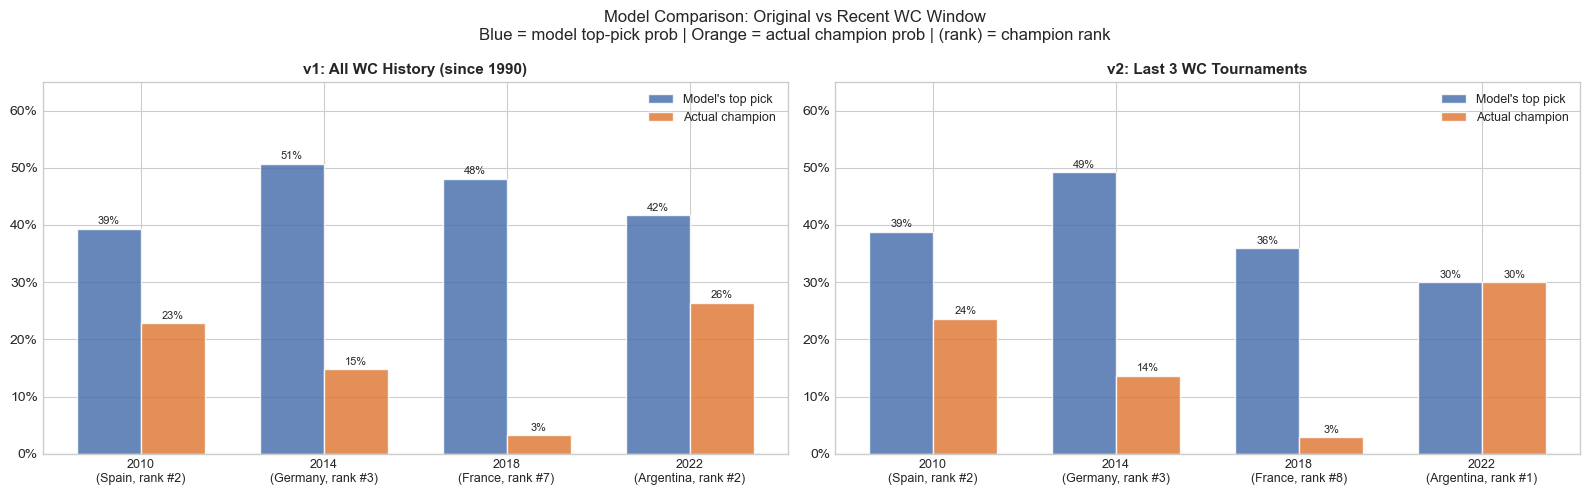

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (result_dict, title) in zip(axes, [
    (backtest_results,    'v1: All WC History (since 1990)'),
    (backtest_results_v2, 'v2: Last 3 WC Tournaments'),
]):
    years_s = sorted(TOURNAMENTS)
    champs  = [TOURNAMENTS[y]['champion'] for y in years_s]
    champ_p = [result_dict[y][TOURNAMENTS[y]['champion']] for y in years_s]
    top_p   = [sorted(result_dict[y].items(), key=lambda x: -x[1])[0][1] for y in years_s]
    ranks_l = []
    for y in years_s:
        ranked = sorted(result_dict[y].items(), key=lambda x: -x[1])
        rank   = next(i + 1 for i, (t, _) in enumerate(ranked)
                      if t == TOURNAMENTS[y]['champion'])
        ranks_l.append(rank)

    x, w = np.arange(len(years_s)), 0.35
    ax.bar(x - w/2, top_p,   w, label="Model's top pick", color='#4c72b0', alpha=0.85, edgecolor='white')
    ax.bar(x + w/2, champ_p, w, label='Actual champion',  color='#e07b39', alpha=0.85, edgecolor='white')

    for xi, (tp, cp) in enumerate(zip(top_p, champ_p)):
        ax.text(xi - w/2, tp + 0.008, f'{tp:.0%}', ha='center', fontsize=8)
        ax.text(xi + w/2, cp + 0.008, f'{cp:.0%}', ha='center', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f'{y}\n({c}, rank #{r})' for y, c, r in zip(years_s, champs, ranks_l)],
        fontsize=9,
    )
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 0.65)

plt.suptitle(
    'Model Comparison: Original vs Recent WC Window\n'
    'Blue = model top-pick prob | Orange = actual champion prob | (rank) = champion rank',
    fontsize=12,
)
plt.tight_layout()
plt.show()


## 8. Feature Improvement: Time-Decayed Elo

**Root cause:** Brazil's base Elo of ~2190 dominates every prediction because the standard Elo system treats a match from 1958 the same as a match from 2017. 150 years of accumulated wins are permanently baked into the rating.

**The fix:** Apply **annual mean reversion** — each year, pull every team's Elo 10% toward 1500. This is the same approach used by FiveThirtyEight's club soccer ratings.

The effect:
- Teams that were dominant decades ago (Brazil 1958–1970) lose that historical credit gradually
- Teams in strong current form maintain high ratings (they keep winning, so reversion is offset)
- Elo differences between top teams compress, making form adjustments more influential
- Combined with v2's recent WC window, this attacks both layers of the Brazil bias


In [17]:
def compute_elo_at_cutoff_v3(df, cutoff, decay_per_year=0.1):
    """Elo with annual mean reversion toward 1500.

    For each team, when they appear in a match, any years elapsed since their
    last match trigger compound reversion: Elo = Elo * (1-d)^n + 1500 * (1-(1-d)^n).
    """
    hist = df[df['date'] < cutoff].sort_values('date')
    elo, last_year, match_rows = {}, {}, []

    for _, row in hist.iterrows():
        h, a     = row['home_team'], row['away_team']
        row_year = row['date'].year

        for team in [h, a]:
            if team not in elo:
                elo[team]      = 1500.0
                last_year[team] = row_year
            years_elapsed = row_year - last_year[team]
            if years_elapsed > 0:
                factor     = (1 - decay_per_year) ** years_elapsed
                elo[team]  = elo[team] * factor + 1500.0 * (1 - factor)
            last_year[team] = row_year

        he, ae = elo[h], elo[a]
        ha     = 0 if row['neutral'] else 100
        exp_h  = 1 / (1 + 10 ** (-(he + ha - ae) / 400))
        actual = (1.0 if row['home_score'] > row['away_score']
                  else 0.5 if row['home_score'] == row['away_score'] else 0.0)
        gd     = abs(row['home_score'] - row['away_score'])
        delta  = get_k_factor(row['tournament']) * goal_diff_multiplier(gd) * (actual - exp_h)
        elo[h] += delta
        elo[a] -= delta
        match_rows.append({'date': row['date'], 'neutral': row['neutral'],
                           'elo_diff': he - ae, 'result': actual})

    return elo, pd.DataFrame(match_rows)


def build_team_elos_v3(teams, elo_ratings, df, cutoff, n_wcs=3):
    """Decayed base Elo + form adj + recent WC uplift (v2)."""
    result = {}
    for t in teams:
        ds_name = get_dataset_name(t)
        base    = elo_ratings.get(ds_name, elo_ratings.get(t, 1500.0))
        form    = compute_form_adj(t, df, cutoff)
        wc      = compute_wc_uplift_v2(t, df, cutoff, n_wcs=n_wcs)
        result[t] = base + form + wc
    return result


In [18]:
# Compare base Elo: no decay (v1) vs 10% annual decay (v3) for 2018 WC teams
year_diag = 2018
meta_d    = TOURNAMENTS[year_diag]
cutoff_d  = meta_d['start']
teams_d   = [t for g in meta_d['groups'].values() for t in g]

elo_v1_d, _ = compute_elo_at_cutoff(df, cutoff_d)
elo_v3_d, _ = compute_elo_at_cutoff_v3(df, cutoff_d, decay_per_year=0.1)

diag_rows = []
for t in teams_d:
    ds = get_dataset_name(t)
    e1 = elo_v1_d.get(ds, elo_v1_d.get(t, 1500.0))
    e3 = elo_v3_d.get(ds, elo_v3_d.get(t, 1500.0))
    diag_rows.append({
        'Team': t,
        'Base Elo (no decay)': int(e1),
        'Base Elo (10% decay)': int(e3),
        'Change': int(e3 - e1),
    })

diag_df = pd.DataFrame(diag_rows).sort_values('Change')
print('Base Elo Shift — 2018 WC (10% annual decay vs no decay)\n')
print(diag_df.to_string(index=False))


Base Elo Shift — 2018 WC (10% annual decay vs no decay)

        Team  Base Elo (no decay)  Base Elo (10% decay)  Change
      Brazil                 2190                  1909    -281
   Argentina                 2036                  1767    -268
     Germany                 2118                  1868    -250
       Spain                 2089                  1839    -250
    Colombia                 1987                  1740    -246
      France                 2023                  1779    -243
     Uruguay                 1947                  1705    -241
     England                 1994                  1764    -230
        Peru                 1989                  1768    -220
    Portugal                 2025                  1814    -210
     Belgium                 1983                  1784    -198
     Croatia                 1901                  1706    -195
      Poland                 1881                  1693    -187
 Switzerland                 1932              

In [19]:
DECAY_RATE = 0.1
backtest_results_v3 = {}

for year, meta in sorted(TOURNAMENTS.items()):
    cutoff    = meta['start']
    groups    = meta['groups']
    all_teams = [t for g in groups.values() for t in g]

    elo_ratings, match_df = compute_elo_at_cutoff_v3(df, cutoff, decay_per_year=DECAY_RATE)
    model     = train_model_at_cutoff(match_df)
    team_elos = build_team_elos_v3(all_teams, elo_ratings, df, cutoff, n_wcs=3)
    probs     = sim_historical_wc(groups, team_elos, model, n_sims=N_SIMS)
    backtest_results_v3[year] = probs

    ranked = sorted(probs.items(), key=lambda x: -x[1])
    actual = meta['champion']
    rank   = next(i + 1 for i, (t, _) in enumerate(ranked) if t == actual)
    top5   = [(t, f'{p:.1%}') for t, p in ranked[:5]]
    print(f'{year}  Champion: {actual} (rank #{rank}, {probs[actual]:.1%}) | '
          f'Top pick: {ranked[0][0]} ({ranked[0][1]:.1%})')
    print(f'  Top 5: {top5}')
    print()

print('Done.')


2010  Champion: Spain (rank #2, 25.2%) | Top pick: Brazil (42.2%)
  Top 5: [('Brazil', '42.2%'), ('Spain', '25.2%'), ('Netherlands', '7.6%'), ('Germany', '6.1%'), ('England', '5.4%')]



2014  Champion: Germany (rank #3, 10.3%) | Top pick: Brazil (55.7%)
  Top 5: [('Brazil', '55.7%'), ('Spain', '18.4%'), ('Germany', '10.3%'), ('Argentina', '5.3%'), ('Netherlands', '3.1%')]



2018  Champion: France (rank #9, 2.2%) | Top pick: Brazil (30.4%)
  Top 5: [('Brazil', '30.4%'), ('Germany', '17.2%'), ('Spain', '13.3%'), ('Belgium', '11.1%'), ('Argentina', '5.2%')]



2022  Champion: Argentina (rank #1, 29.8%) | Top pick: Argentina (29.8%)
  Top 5: [('Argentina', '29.8%'), ('Brazil', '24.7%'), ('Netherlands', '22.5%'), ('Belgium', '4.1%'), ('Spain', '4.0%')]

Done.


In [20]:
all_versions = [
    (backtest_results,    'v1: All history'),
    (backtest_results_v2, 'v2: Recent WC window'),
    (backtest_results_v3, 'v3: Decay + Recent'),
]

print('Full Comparison: v1 vs v2 vs v3\n')

for year in sorted(TOURNAMENTS):
    actual = TOURNAMENTS[year]['champion']
    print(f'  {year} — actual champion: {actual}')
    for results, lbl in all_versions:
        ranked   = sorted(results[year].items(), key=lambda x: -x[1])
        rank     = next(i + 1 for i, (t, _) in enumerate(ranked) if t == actual)
        top_pick = ranked[0][0]
        prob     = results[year][actual]
        correct  = 'CORRECT' if top_pick == actual else f'picked {top_pick}'
        print(f'    {lbl:<24} rank #{rank} ({prob:.1%}) — {correct}')
    print()

print('Aggregate Metrics')
print(f'  {"Version":<24}  Top-1  Top-3  Avg rank  Avg prob')
print('  ' + '-' * 55)
for results, lbl in all_versions:
    ranks_l, probs_l, top1, top3 = [], [], 0, 0
    for year in sorted(TOURNAMENTS):
        actual  = TOURNAMENTS[year]['champion']
        ranked  = sorted(results[year].items(), key=lambda x: -x[1])
        rank    = next(i + 1 for i, (t, _) in enumerate(ranked) if t == actual)
        ranks_l.append(rank)
        probs_l.append(results[year][actual])
        if rank == 1: top1 += 1
        if rank <= 3: top3 += 1
    print(f'  {lbl:<24}  {top1}/4    {top3}/4    {np.mean(ranks_l):.1f}       {np.mean(probs_l):.1%}')


Full Comparison: v1 vs v2 vs v3

  2010 — actual champion: Spain
    v1: All history          rank #2 (22.9%) — picked Brazil
    v2: Recent WC window     rank #2 (23.6%) — picked Brazil
    v3: Decay + Recent       rank #2 (25.2%) — picked Brazil

  2014 — actual champion: Germany
    v1: All history          rank #3 (14.8%) — picked Brazil
    v2: Recent WC window     rank #3 (13.7%) — picked Brazil
    v3: Decay + Recent       rank #3 (10.3%) — picked Brazil

  2018 — actual champion: France
    v1: All history          rank #7 (3.2%) — picked Brazil
    v2: Recent WC window     rank #8 (2.9%) — picked Brazil
    v3: Decay + Recent       rank #9 (2.2%) — picked Brazil

  2022 — actual champion: Argentina
    v1: All history          rank #2 (26.4%) — picked Brazil
    v2: Recent WC window     rank #1 (29.9%) — CORRECT
    v3: Decay + Recent       rank #1 (29.8%) — CORRECT

Aggregate Metrics
  Version                   Top-1  Top-3  Avg rank  Avg prob
  ------------------------------

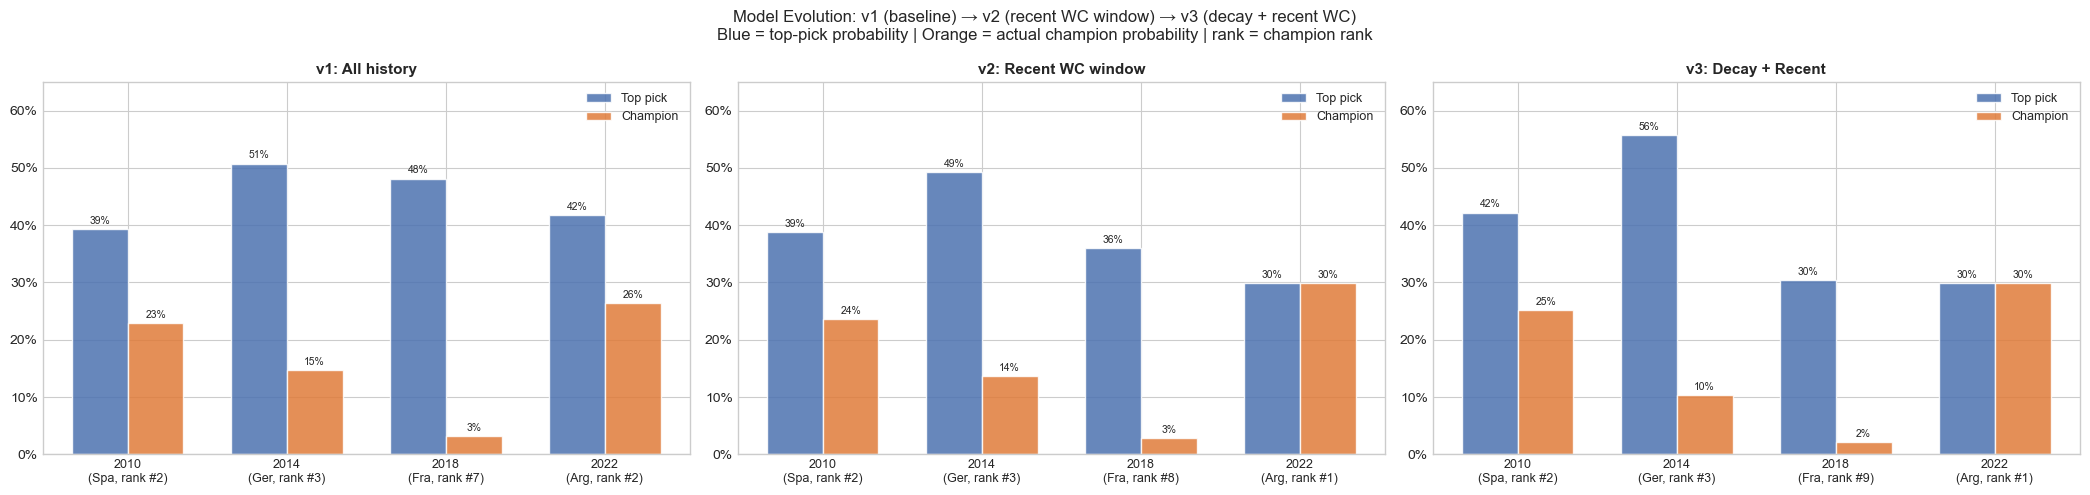

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

for ax, (result_dict, title) in zip(axes, all_versions):
    years_s = sorted(TOURNAMENTS)
    champs  = [TOURNAMENTS[y]['champion'] for y in years_s]
    champ_p = [result_dict[y][TOURNAMENTS[y]['champion']] for y in years_s]
    top_p   = [sorted(result_dict[y].items(), key=lambda x: -x[1])[0][1] for y in years_s]
    ranks_l = []
    for y in years_s:
        ranked = sorted(result_dict[y].items(), key=lambda x: -x[1])
        rank   = next(i + 1 for i, (t, _) in enumerate(ranked)
                      if t == TOURNAMENTS[y]['champion'])
        ranks_l.append(rank)

    x, w = np.arange(len(years_s)), 0.35
    ax.bar(x - w/2, top_p,   w, label='Top pick', color='#4c72b0', alpha=0.85, edgecolor='white')
    ax.bar(x + w/2, champ_p, w, label='Champion',  color='#e07b39', alpha=0.85, edgecolor='white')

    for xi, (tp, cp) in enumerate(zip(top_p, champ_p)):
        ax.text(xi - w/2, tp + 0.009, f'{tp:.0%}', ha='center', fontsize=7.5)
        ax.text(xi + w/2, cp + 0.009, f'{cp:.0%}', ha='center', fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f'{y}\n({c[:3]}, rank #{r})' for y, c, r in zip(years_s, champs, ranks_l)],
        fontsize=9,
    )
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 0.65)

plt.suptitle(
    'Model Evolution: v1 (baseline) → v2 (recent WC window) → v3 (decay + recent WC)\n'
    'Blue = top-pick probability | Orange = actual champion probability | rank = champion rank',
    fontsize=12,
)
plt.tight_layout()
plt.show()


## 9. Feature: Squad Trajectory (Age Proxy)

**Motivation:** The 2018 France miss (rank #8) and the structural gap we identified: Elo captures *accumulated* performance, not whether a team is on an upward or downward trajectory. A young squad peaking — like France 2018 (Mbappé 19, Kanté, Pogba in form) — will be undervalued because their recent *improvement* isn't reflected in the Elo level alone.

**Feature: Elo Velocity** — the annual rate of Elo change over the 2 years before the tournament. Computed entirely from match history; no external squad data needed.

- **Positive velocity** → team is improving → often a young squad coming into form
- **Negative velocity** → team is declining → often an aging squad past peak
- Scaled to ±30 Elo (smaller than form ±75 or WC uplift ±40 — trajectory is a softer signal)

This is a **proxy** for squad age dynamics. True squad age would require a player-level dataset (e.g., tournament squad databases), but Elo trajectory captures the same underlying effect from match results alone.

**v4 = v2 (recent WC window) + Elo velocity**


In [22]:
def compute_elo_with_snapshot(df, cutoff, snapshot_lookback_years=2):
    """Single-pass Elo computation that also captures a mid-point snapshot.

    Returns (elo_current, elo_snapshot, match_df) where elo_snapshot is the
    Elo dict as of (cutoff - snapshot_lookback_years). Used to compute velocity
    without a second full pass through the dataset.
    """
    snapshot_date = cutoff - pd.DateOffset(years=snapshot_lookback_years)
    hist = df[df['date'] < cutoff].sort_values('date')
    elo = {}
    elo_snapshot = {}
    snapshot_taken = False
    match_rows = []

    for _, row in hist.iterrows():
        if not snapshot_taken and row['date'] >= snapshot_date:
            elo_snapshot = elo.copy()
            snapshot_taken = True

        h, a = row['home_team'], row['away_team']
        if h not in elo: elo[h] = 1500.0
        if a not in elo: elo[a] = 1500.0

        he, ae = elo[h], elo[a]
        ha = 0 if row['neutral'] else 100
        exp_h = 1 / (1 + 10 ** (-(he + ha - ae) / 400))
        actual = (1.0 if row['home_score'] > row['away_score']
                  else 0.5 if row['home_score'] == row['away_score'] else 0.0)
        gd = abs(row['home_score'] - row['away_score'])
        delta = get_k_factor(row['tournament']) * goal_diff_multiplier(gd) * (actual - exp_h)
        elo[h] += delta
        elo[a] -= delta
        match_rows.append({'date': row['date'], 'neutral': row['neutral'],
                           'elo_diff': he - ae, 'result': actual})

    if not snapshot_taken:
        elo_snapshot = elo.copy()   # no data before snapshot_date

    return elo, elo_snapshot, pd.DataFrame(match_rows)


def compute_elo_velocity(wc_name, elo_current, elo_snapshot, lookback_years=2):
    """Annual Elo improvement rate over the past lookback_years → momentum adjustment.

    Scale: ±200 Elo/year change maps to the ±30 max adjustment.
    A typical strong improvement of +75/yr → +11 Elo boost.
    """
    team     = get_dataset_name(wc_name)
    elo_now  = elo_current.get(team, 1500.0)
    elo_then = elo_snapshot.get(team, elo_now)   # default: no change
    annual_rate = (elo_now - elo_then) / lookback_years
    return float(np.clip(annual_rate * 0.15, -30, 30))


def build_team_elos_v4(teams, elo_current, elo_snapshot, df, cutoff, n_wcs=3):
    """v2 enrichment + Elo velocity (squad trajectory / age proxy)."""
    result = {}
    for t in teams:
        ds   = get_dataset_name(t)
        base = elo_current.get(ds, elo_current.get(t, 1500.0))
        form = compute_form_adj(t, df, cutoff)
        wc   = compute_wc_uplift_v2(t, df, cutoff, n_wcs=n_wcs)
        vel  = compute_elo_velocity(t, elo_current, elo_snapshot)
        result[t] = base + form + wc + vel
    return result


In [23]:
# Show velocity for all 2018 WC teams — the key question is: does France get a boost?
year_diag = 2018
meta_d    = TOURNAMENTS[year_diag]
cutoff_d  = meta_d['start']
teams_d   = [t for g in meta_d['groups'].values() for t in g]

elo_cur, elo_snap, _ = compute_elo_with_snapshot(df, cutoff_d, snapshot_lookback_years=2)

diag_rows = []
for t in teams_d:
    ds   = get_dataset_name(t)
    now  = elo_cur.get(ds,  elo_cur.get(t,  1500.0))
    then = elo_snap.get(ds, elo_snap.get(t, 1500.0))
    vel  = compute_elo_velocity(t, elo_cur, elo_snap)
    diag_rows.append({
        'Team':         t,
        'Elo (2016)':   int(then),
        'Elo (2018)':   int(now),
        '2yr change':   int(now - then),
        'Velocity adj': round(vel, 1),
    })

diag_df = pd.DataFrame(diag_rows).sort_values('Velocity adj', ascending=False)
print('Squad Trajectory — 2018 World Cup  (2-year Elo velocity, 2016→2018)\n')
print(diag_df.to_string(index=False))


Squad Trajectory — 2018 World Cup  (2-year Elo velocity, 2016→2018)

        Team  Elo (2016)  Elo (2018)  2yr change  Velocity adj
     Morocco        1661        1812         151          11.4
      Brazil        2042        2190         148          11.1
        Peru        1850        1989         138          10.4
 Switzerland        1818        1932         113           8.5
     Iceland        1715        1829         113           8.5
     Denmark        1770        1881         111           8.3
      Serbia        1725        1808          83           6.2
     Tunisia        1692        1772          80           6.1
    Portugal        1952        2025          72           5.5
     Belgium        1915        1983          68           5.1
     Senegal        1795        1857          62           4.7
        Iran        1841        1885          43           3.3
     Germany        2075        2118          42           3.2
       Spain        2049        2089          40 

In [24]:
backtest_results_v4 = {}

for year, meta in sorted(TOURNAMENTS.items()):
    cutoff    = meta['start']
    groups    = meta['groups']
    all_teams = [t for g in groups.values() for t in g]

    elo_cur, elo_snap, match_df = compute_elo_with_snapshot(df, cutoff, snapshot_lookback_years=2)
    model     = train_model_at_cutoff(match_df)
    team_elos = build_team_elos_v4(all_teams, elo_cur, elo_snap, df, cutoff, n_wcs=3)
    probs     = sim_historical_wc(groups, team_elos, model, n_sims=N_SIMS)
    backtest_results_v4[year] = probs

    ranked = sorted(probs.items(), key=lambda x: -x[1])
    actual = meta['champion']
    rank   = next(i + 1 for i, (t, _) in enumerate(ranked) if t == actual)
    top5   = [(t, f'{p:.1%}') for t, p in ranked[:5]]
    print(f'{year}  Champion: {actual} (rank #{rank}, {probs[actual]:.1%}) | '
          f'Top pick: {ranked[0][0]} ({ranked[0][1]:.1%})')
    print(f'  Top 5: {top5}')
    print()

print('Done.')


2010  Champion: Spain (rank #2, 24.9%) | Top pick: Brazil (38.1%)
  Top 5: [('Brazil', '38.1%'), ('Spain', '24.9%'), ('Netherlands', '10.3%'), ('England', '8.0%'), ('Germany', '6.9%')]



2014  Champion: Germany (rank #3, 13.6%) | Top pick: Brazil (49.3%)
  Top 5: [('Brazil', '49.3%'), ('Spain', '20.5%'), ('Germany', '13.6%'), ('Argentina', '7.3%'), ('Netherlands', '3.1%')]



2018  Champion: France (rank #8, 2.9%) | Top pick: Brazil (38.0%)
  Top 5: [('Brazil', '38.0%'), ('Germany', '15.5%'), ('Spain', '13.4%'), ('Argentina', '6.8%'), ('Belgium', '6.7%')]



2022  Champion: Argentina (rank #1, 32.1%) | Top pick: Argentina (32.1%)
  Top 5: [('Argentina', '32.1%'), ('Brazil', '29.2%'), ('Netherlands', '15.7%'), ('Belgium', '5.4%'), ('Spain', '4.7%')]

Done.


In [25]:
all_versions_full = [
    (backtest_results,    'v1: All WC history'),
    (backtest_results_v2, 'v2: Recent WC window'),
    (backtest_results_v3, 'v3: Decay + Recent'),
    (backtest_results_v4, 'v4: v2 + Trajectory'),
]

print('Full Comparison: v1 / v2 / v3 / v4\n')
for year in sorted(TOURNAMENTS):
    actual = TOURNAMENTS[year]['champion']
    print(f'  {year} — champion: {actual}')
    for results, lbl in all_versions_full:
        ranked   = sorted(results[year].items(), key=lambda x: -x[1])
        rank     = next(i + 1 for i, (t, _) in enumerate(ranked) if t == actual)
        top_pick = ranked[0][0]
        prob     = results[year][actual]
        correct  = 'CORRECT' if top_pick == actual else f'picked {top_pick}'
        print(f'    {lbl:<24} rank #{rank} ({prob:.1%}) — {correct}')
    print()

print('Aggregate Metrics')
print(f'  {"Version":<24}  Top-1  Top-3  Avg rank  Avg champion prob')
print('  ' + '-' * 60)
for results, lbl in all_versions_full:
    ranks_l, probs_l, top1, top3 = [], [], 0, 0
    for year in sorted(TOURNAMENTS):
        actual  = TOURNAMENTS[year]['champion']
        ranked  = sorted(results[year].items(), key=lambda x: -x[1])
        rank    = next(i + 1 for i, (t, _) in enumerate(ranked) if t == actual)
        ranks_l.append(rank)
        probs_l.append(results[year][actual])
        if rank == 1: top1 += 1
        if rank <= 3: top3 += 1
    print(f'  {lbl:<24}  {top1}/4    {top3}/4    {np.mean(ranks_l):.1f}       {np.mean(probs_l):.1%}')


Full Comparison: v1 / v2 / v3 / v4

  2010 — champion: Spain
    v1: All WC history       rank #2 (22.9%) — picked Brazil
    v2: Recent WC window     rank #2 (23.6%) — picked Brazil
    v3: Decay + Recent       rank #2 (25.2%) — picked Brazil
    v4: v2 + Trajectory      rank #2 (24.9%) — picked Brazil

  2014 — champion: Germany
    v1: All WC history       rank #3 (14.8%) — picked Brazil
    v2: Recent WC window     rank #3 (13.7%) — picked Brazil
    v3: Decay + Recent       rank #3 (10.3%) — picked Brazil
    v4: v2 + Trajectory      rank #3 (13.6%) — picked Brazil

  2018 — champion: France
    v1: All WC history       rank #7 (3.2%) — picked Brazil
    v2: Recent WC window     rank #8 (2.9%) — picked Brazil
    v3: Decay + Recent       rank #9 (2.2%) — picked Brazil
    v4: v2 + Trajectory      rank #8 (2.9%) — picked Brazil

  2022 — champion: Argentina
    v1: All WC history       rank #2 (26.4%) — picked Brazil
    v2: Recent WC window     rank #1 (29.9%) — CORRECT
    v3: De

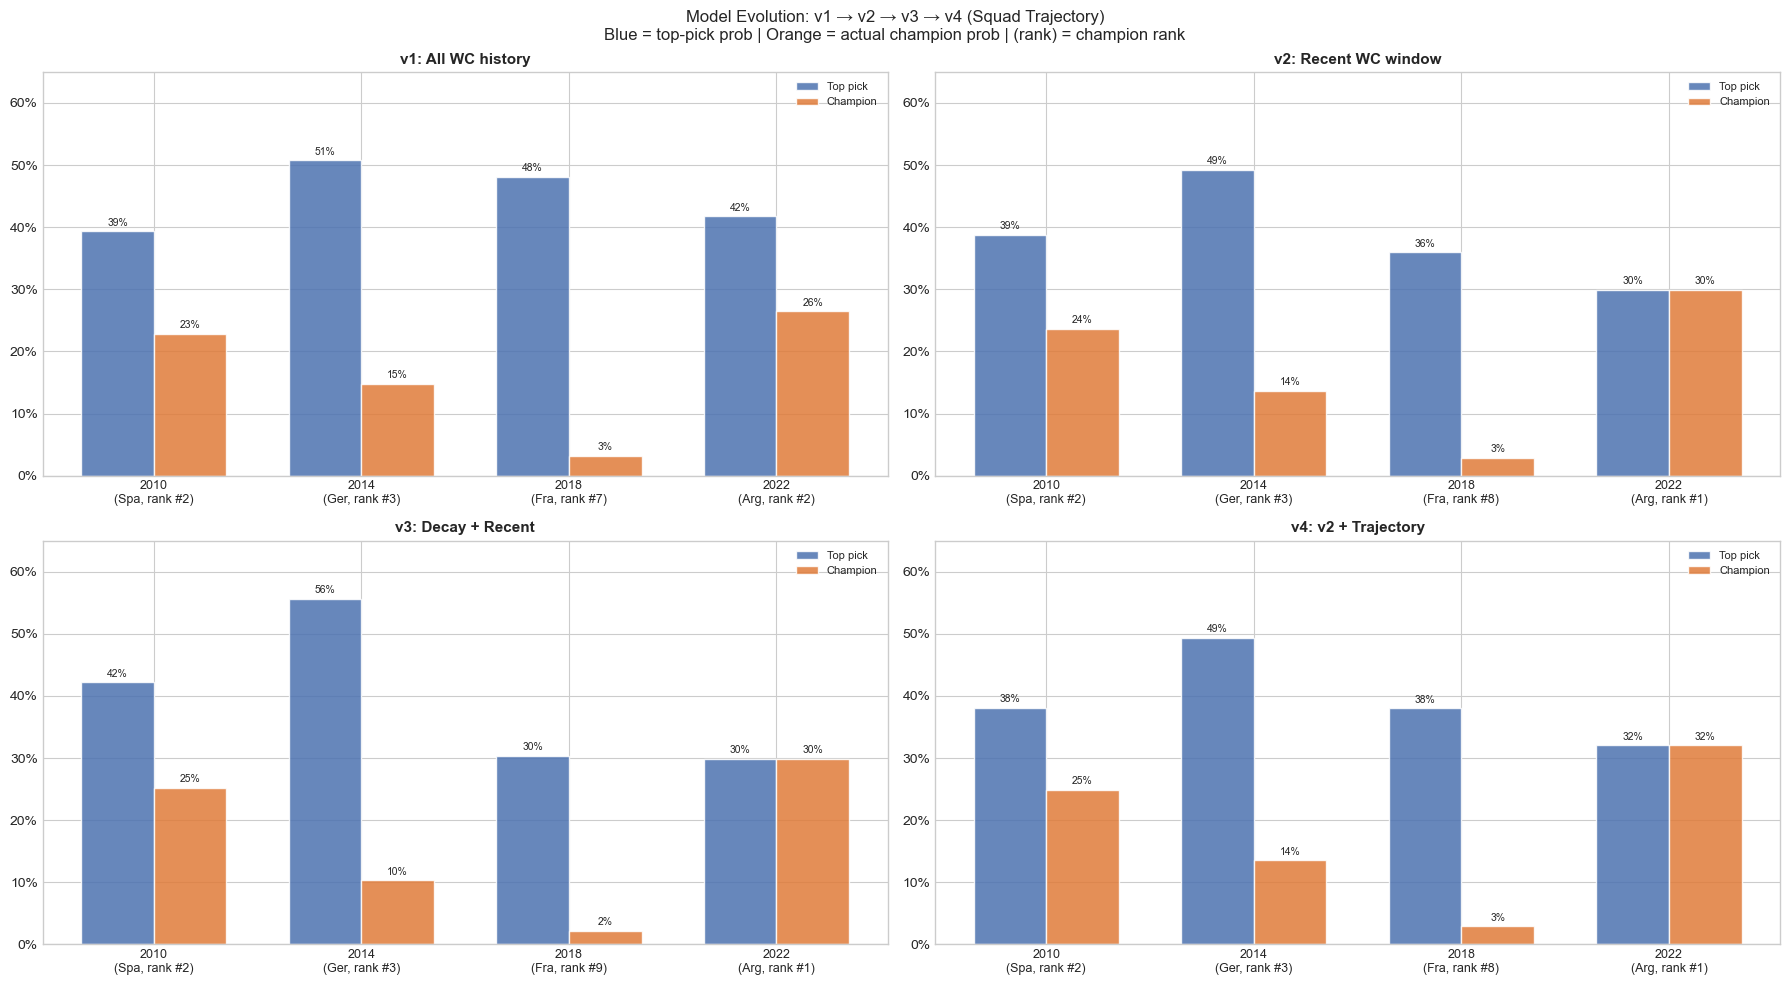

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for ax, (results, title) in zip(axes, all_versions_full):
    years_s = sorted(TOURNAMENTS)
    champs  = [TOURNAMENTS[y]['champion'] for y in years_s]
    champ_p = [results[y][TOURNAMENTS[y]['champion']] for y in years_s]
    top_p   = [sorted(results[y].items(), key=lambda x: -x[1])[0][1] for y in years_s]
    ranks_l = []
    for y in years_s:
        ranked = sorted(results[y].items(), key=lambda x: -x[1])
        rank   = next(i + 1 for i, (t, _) in enumerate(ranked)
                      if t == TOURNAMENTS[y]['champion'])
        ranks_l.append(rank)

    x, w = np.arange(len(years_s)), 0.35
    ax.bar(x - w/2, top_p,   w, label='Top pick', color='#4c72b0', alpha=0.85, edgecolor='white')
    ax.bar(x + w/2, champ_p, w, label='Champion',  color='#e07b39', alpha=0.85, edgecolor='white')

    for xi, (tp, cp) in enumerate(zip(top_p, champ_p)):
        ax.text(xi - w/2, tp + 0.009, f'{tp:.0%}', ha='center', fontsize=7.5)
        ax.text(xi + w/2, cp + 0.009, f'{cp:.0%}', ha='center', fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f'{y}\n({c[:3]}, rank #{r})' for y, c, r in zip(years_s, champs, ranks_l)],
        fontsize=9,
    )
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 0.65)

plt.suptitle(
    'Model Evolution: v1 → v2 → v3 → v4 (Squad Trajectory)\n'
    'Blue = top-pick prob | Orange = actual champion prob | (rank) = champion rank',
    fontsize=12,
)
plt.tight_layout()
plt.show()
